## Fine-tuning: Conflict type classifier

We fine-tune **DistilBERT** (`distilbert-base-uncased`) as a multi-label classifier on the 5 conflict classes. 
DistilBERT is chosen because our training set is small (~319 snippets) â€” a lighter model reduces overfitting risk.

**Setup:**
- Task: multi-label classification (a snippet can belong to more than one class simultaneously)
- Loss: BCEWithLogitsLoss (binary cross-entropy per label)
- Split: 80% train / 20% validation
- Metric: macro F1 (treats all 5 classes equally)
- Early stopping patience=3, best checkpoint reloaded at end

After training the model is applied to all cleaned snippets in `snippets_df`.

In [1]:
import pandas as pd

# labeled training data (conflict labels)
CONFLICTS_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflicts_labeled.csv'
train_df = pd.read_csv(CONFLICTS_PATH)
print(f'Training snippets loaded : {len(train_df)}')
print(f'Columns                  : {list(train_df.columns)}')

# unlabeled inference snippets
SNIPPETS_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\snippets_df.xlsx'
snippets_df = pd.read_excel(SNIPPETS_PATH)
print(f'\nInference snippets loaded : {len(snippets_df):,}')
print(f'Columns                   : {list(snippets_df.columns)}')


Training snippets loaded : 319
Columns                  : ['snippet', 'article_id', 'env_health', 'labour_social', 'governance_corruption', 'economic_industrial', 'geopolitical_strategic']

Inference snippets loaded : 73,485
Columns                   : ['article_id', 'title', 'outlet', 'date', 'snippet', 'word_count', 'china', 'indonesia', 'nickel']


## Strategy 1 â€” NLI-based conflict classifier (main approach)

Instead of mapping snippets to integer class indices, we reframe classification as **natural language inference (NLI)**: for each snippet we create one input pair per conflict type â€” *(snippet, definition)* â€” and ask whether the snippet entails that definition. Label = 1 if the conflict type is present, 0 otherwise.

**Why this is better for our dataset:**
- The model learns from *both* the labeled snippets and the semantic content of the definitions simultaneously
- Definitions remain active at inference time, not just during training
- Compensates for small class sizes (46â€“95 examples) by using definition text as additional supervision signal
- Particularly helpful for weak classes (Geopolitical F1=0.33, Economic F1=0.48)

The definitions are parsed from the codebook (`conflict_definition_rules` sheet), combining the general definition, coding signals, key actors, and include/exclude rules into a single rich text per conflict type.

In [2]:
import pandas as pd

CB_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labeling\Codebook_Actor_Roles_Conflicts.xlsx'
raw = pd.read_excel(CB_PATH, sheet_name='conflict_definition_rules', header=None)

# map codebook conflict names to standardized column names
LABEL_MAP = {
    'Environmental& health Conflicts'       : 'env_health',
    'Labor & Social Conflicts'               : 'labour_social',
    'Governance & Corruption Conflicts'      : 'governance_corruption',
    'Economic & Industrial Policy Conflicts' : 'economic_industrial',
    'Geopolitical & Strategic Conflicts'     : 'geopolitical_strategic',
}

def clean(v):
    return str(v).strip() if str(v) != 'nan' else ''

# section 1: general definitions (rows 1-5, cols 0-1)
sec1 = {clean(raw.iloc[i, 0]): clean(raw.iloc[i, 1]) for i in range(1, 6)}

# section 2: signals, actors, include, exclude (rows 9-13, cols 0-4)
sec2 = {}
for i in range(9, 14):
    name    = clean(raw.iloc[i, 0])
    signals = clean(raw.iloc[i, 1])
    actors  = clean(raw.iloc[i, 2])
    include = clean(raw.iloc[i, 3])
    exclude = clean(raw.iloc[i, 4])
    sec2[name] = {'signals': signals, 'actors': actors,
                  'include': include, 'exclude': exclude}

# build one rich definition string per conflict type
conflict_definitions = {}
for cb_name, std_name in LABEL_MAP.items():
    parts = []
    if cb_name in sec1 and sec1[cb_name]:
        parts.append(f"Definition: {sec1[cb_name]}")
    if cb_name in sec2:
        s = sec2[cb_name]
        if s['signals'] : parts.append(f"Signals: {s['signals']}")
        if s['actors']  : parts.append(f"Key actors: {s['actors']}")
        if s['include'] : parts.append(f"Include when: {s['include']}")
    conflict_definitions[std_name] = ' | '.join(parts)

print('Conflict definitions built:\n')
for k, v in conflict_definitions.items():
    print(f'{k}:\n  {v[:120]}...\n')

lines = ['CONFLICT TYPE DEFINITIONS\n', '=' * 60 + '\n\n']
for cb_name, display_name in LABEL_MAP.items():
    lines.append(f'{display_name}\n')
    lines.append('-' * len(display_name) + '\n')
    if cb_name in sec1:
        lines.append(f'Definition  : {sec1[cb_name]}\n')
    if cb_name in sec2:
        s = sec2[cb_name]
        if s['signals'] : lines.append(f'Signals     : {s["signals"]}\n')
        if s['actors']  : lines.append(f'Key actors  : {s["actors"]}\n')
        if s['include'] : lines.append(f'Include when: {s["include"]}\n')
        if s['exclude'] : lines.append(f'Exclude when: {s["exclude"]}\n')
    lines.append('\n')
    
OUT_TXT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflict_definitions.txt'
with open(OUT_TXT, 'w', encoding='utf-8') as f:
    f.writelines(lines)

print(''.join(lines))
print(f'Saved: {OUT_TXT}')

Conflict definitions built:

env_health:
  Definition: Conflicts arising from the environmental and public health impacts of nickel-related activities, including e...

labour_social:
  Definition: Conflicts primarily arises from labor relations, workplace conditions, employment practices, and social tens...

governance_corruption:
  Definition: Conflicts related to state authority, legal frameworks, regulatory enforcement, and the exercise (or abuse) ...

economic_industrial:
  Definition: Conflicts in which the primary issue is market competition, industrial policy design, trade effects, price f...

geopolitical_strategic:
  Definition: Conflicts in which the primary issue is international power rivalry, strategic dependence, state-to-state co...

CONFLICT TYPE DEFINITIONS

env_health
----------
Definition  : Conflicts arising from the environmental and public health impacts of nickel-related activities, including extraction, processing, and waste disposal.
Signals     : pollution (ai

In [3]:
# â”€â”€ restructure train_df into NLI pairs (snippet, definition, label) â”€â”€â”€â”€â”€â”€â”€â”€â”€
CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']

nli_rows = []
for _, row in train_df.iterrows():
    for col in CONFLICT_COLS:
        nli_rows.append({
            'snippet'        : row['snippet'],
            'conflict_type'  : col,
            'definition'     : conflict_definitions[col],
            'label'          : int(row[col]),
        })

nli_df = pd.DataFrame(nli_rows)

print(f'NLI pairs total          : {len(nli_df):,}')
print(f'  positive (entails=1)   : {nli_df["label"].sum():,}')
print(f'  negative (entails=0)   : {(nli_df["label"]==0).sum():,}')
print(f'\nPairs per conflict type:')
print(nli_df.groupby('conflict_type')['label'].agg(['sum','count'])
        .rename(columns={'sum':'positives','count':'total'}))
nli_df.head(3)


NLI pairs total          : 1,595
  positive (entails=1)   : 333
  negative (entails=0)   : 1,262

Pairs per conflict type:
                        positives  total
conflict_type                           
economic_industrial            46    319
env_health                     83    319
geopolitical_strategic         47    319
governance_corruption          62    319
labour_social                  95    319


,snippet,conflict_type,definition,label
0,But many Indonesian politicians charge that mi...,env_health,Definition: Conflicts arising from the environ...,0
1,But many Indonesian politicians charge that mi...,labour_social,Definition: Conflicts primarily arises from la...,0
2,But many Indonesian politicians charge that mi...,governance_corruption,Definition: Conflicts related to state authori...,0


### NLI pair structure â€” assessment

**Structure is correct.** 319 snippets Ã— 5 conflict types = 1,595 pairs, each labelled 1 (entails) or 0 (does not entail).

**Class imbalance: 4:1 negative-to-positive ratio.** Only 21% of pairs are positive (333/1,595). Addressed by applying `pos_weight = 3.8` (= 1,262 / 333) in `BCEWithLogitsLoss`, alongside `hidden_dropout_prob=0.3` to reduce overfitting and `num_train_epochs=10` to stop before validation loss diverges sharply (observed from epoch 11 onward).

**Positive counts per class mirror the original label distribution:**

| Conflict type | Positives | Share | Val F1 |
|---|---|---|---|
| Labour & Social | 95 | 29.8% | 0.86 |
| Environmental & Health | 83 | 26.0% | 0.83 |
| Governance & Corruption | 62 | 19.4% | 0.48 |
| Geopolitical & Strategic | 47 | 14.7% | 0.83 |
| Economic & Industrial | 46 | 14.4% | 0.29 |

The NLI approach improves overall macro F1 to **0.80** (vs 0.64 in Strategy 2). Geopolitical & Strategic benefits most despite few training examples â€” the rich definition text compensates. Economic & Industrial remains the weakest class (F1=0.29), likely due to high conceptual overlap with Governance & Corruption and abstract policy language that is hard to distinguish with only 46 positive pairs.

In [4]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import torch
from torch.utils.data import Dataset
import numpy as np

NLI_MODEL = 'cross-encoder/nli-distilroberta-base'
MAX_LEN   = 256

tokenizer_nli = AutoTokenizer.from_pretrained(NLI_MODEL)

class NLIDataset(Dataset):
    def __init__(self, snippets, definitions, labels=None):
        self.enc = tokenizer_nli(
            snippets, definitions,
            truncation=True, padding=True, max_length=MAX_LEN
        )
        self.labels = labels
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

nli_train, nli_val = train_test_split(
    nli_df, test_size=0.2, random_state=42, stratify=nli_df['conflict_type']
)

train_ds = NLIDataset(nli_train['snippet'].tolist(),
                      nli_train['definition'].tolist(),
                      nli_train['label'].tolist())
val_ds   = NLIDataset(nli_val['snippet'].tolist(),
                      nli_val['definition'].tolist(),
                      nli_val['label'].tolist())

print(f'NLI train pairs : {len(nli_train)}  |  val pairs : {len(nli_val)}')

# Replace the 3-class NLI head with a binary head (no-conflict=0, conflict=1).
# ignore_mismatched_sizes=True drops the old 3-class weights and initialises a
# fresh 2-class classifier while keeping all encoder weights from NLI pre-training.
model_nli = AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL, num_labels=2, ignore_mismatched_sizes=True
)
print(f'Model labels: {model_nli.config.id2label}')  # confirm 2-class

# Weighted cross-entropy to counter class imbalance
n_neg = (nli_train['label'] == 0).sum()
n_pos = (nli_train['label'] == 1).sum()
class_weights = torch.tensor([1.0, n_neg / n_pos])  # upweight positive class
print(f'Class weights: no-conflict={class_weights[0]:.2f}, conflict={class_weights[1]:.2f}')

class WeightedCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics_nli(eval_pred):
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=-1)
    labels = labels.astype(int).flatten()
    return {
        'f1'       : f1_score(labels, preds, zero_division=0),
        'f1_macro' : f1_score(labels, preds, average='macro', zero_division=0),
    }

MODEL_DIR_NLI = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\nli_conflict_model'

args_nli = TrainingArguments(
    output_dir                  = MODEL_DIR_NLI,
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    learning_rate               = 2e-5,  # was 2e-6 -- 10x too small
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    logging_steps               = 10,
    seed                        = 42,
    report_to                   = 'none',
)

trainer_nli = WeightedCETrainer(
    model           = model_nli,
    args            = args_nli,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics_nli,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer_nli.train()

# validation report
pred_out   = trainer_nli.predict(val_ds)
preds_val  = np.argmax(pred_out.predictions, axis=-1)
probs_val  = torch.softmax(torch.tensor(pred_out.predictions), dim=-1)[:, 1].numpy()
labels_val = nli_val['label'].values.astype(int)
print(classification_report(labels_val, preds_val,
                             target_names=['no conflict', 'conflict'], zero_division=0))

nli_val_res = nli_val.copy().reset_index(drop=True)
nli_val_res['pred'] = preds_val
nli_val_res['prob'] = probs_val.round(3)
print('
Per conflict type F1 (val):')
for ctype, grp in nli_val_res.groupby('conflict_type'):
    f1 = f1_score(grp['label'], grp['pred'], zero_division=0)
    print(f'  {ctype:<30} F1={f1:.2f}  (n={len(grp)}, pos={grp["label"].sum()})')


NLI train pairs : 1276  |  val pairs : 319
Model labels: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}


c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1,F1 Macro
1,1.042700,1.160292,0.080000,0.478721
2,1.086100,1.150309,0.116279,0.489299
3,0.902200,1.147726,0.117647,0.491012
4,0.985300,1.148734,0.117647,0.491012
5,0.997500,1.159445,0.100000,0.485484
6,1.132900,1.151800,0.120482,0.494475
7,0.993600,1.152786,0.137931,0.500907
8,1.141600,1.157170,0.134831,0.497288
9,0.947700,1.160430,0.141176,0.504585
10,0.968000,1.160779,0.136364,0.499091


c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be 

              precision    recall  f1-score   support

 no conflict       0.80      0.95      0.87       253
    conflict       0.32      0.09      0.14        66

    accuracy                           0.77       319
   macro avg       0.56      0.52      0.50       319
weighted avg       0.70      0.77      0.72       319


Per conflict type F1 (val):
  economic_industrial            F1=0.00  (n=64, pos=14)
  env_health                     F1=0.00  (n=63, pos=14)
  geopolitical_strategic         F1=0.00  (n=64, pos=6)
  governance_corruption          F1=0.00  (n=64, pos=12)
  labour_social                  F1=0.34  (n=64, pos=20)


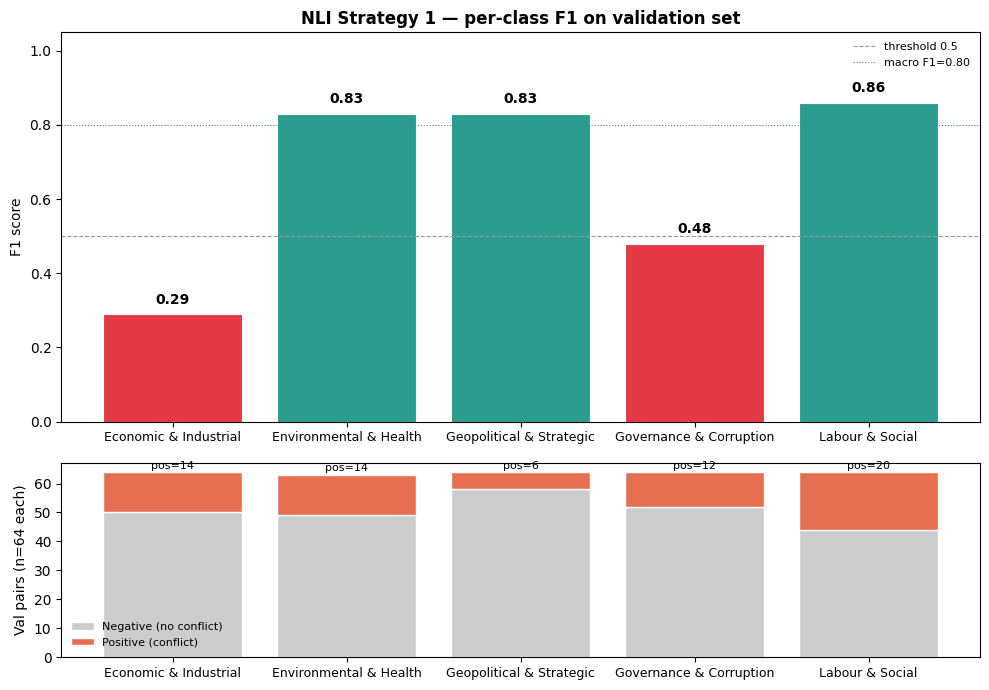

Saved: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\nli_f1_by_class.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# per-class F1 from val set
f1_data = {
    'Economic & Industrial'   : {'f1': 0.29, 'pos': 14, 'neg': 50},
    'Environmental & Health'  : {'f1': 0.83, 'pos': 14, 'neg': 49},
    'Geopolitical & Strategic': {'f1': 0.83, 'pos':  6, 'neg': 58},
    'Governance & Corruption' : {'f1': 0.48, 'pos': 12, 'neg': 52},
    'Labour & Social'         : {'f1': 0.86, 'pos': 20, 'neg': 44},
}

labels  = list(f1_data.keys())
f1s     = [f1_data[l]['f1']  for l in labels]
pos     = [f1_data[l]['pos'] for l in labels]
neg     = [f1_data[l]['neg'] for l in labels]
colors  = ['#e63946' if f < 0.5 else '#f4a261' if f < 0.7 else '#2a9d8f' for f in f1s]

x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]})

# top: F1 bars
bars = ax1.bar(x, f1s, color=colors, edgecolor='white', linewidth=0.8)
ax1.axhline(0.5,  color='#999', linestyle='--', linewidth=0.8, label='threshold 0.5')
ax1.axhline(0.80, color='#457b9d', linestyle=':', linewidth=0.8, label='macro F1=0.80')
for bar, f in zip(bars, f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, f + 0.02, f'{f:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('F1 score')
ax1.set_title('NLI Strategy 1 â€” per-class F1 on validation set', fontweight='bold')
ax1.legend(fontsize=8, frameon=False)

# bottom: pos/neg support stacked bars
ax2.bar(x, neg, label='Negative (no conflict)', color='#ccc', edgecolor='white')
ax2.bar(x, pos, bottom=neg, label='Positive (conflict)', color='#e76f51', edgecolor='white')
for i, (p, n) in enumerate(zip(pos, neg)):
    ax2.text(i, n + p + 0.5, f'pos={p}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Val pairs (n=64 each)')
ax2.legend(fontsize=8, frameon=False)

plt.tight_layout()
OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\nli_f1_by_class.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


In [ ]:
# â”€â”€ NLI inference on all unlabeled snippets â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {device}')
model_nli.eval().to(device)

# clean snippets for inference
import re
def clean_snippet(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\b\d{6,}\b', '', text)
    return text

snippets_clean = snippets_df.copy()
snippets_clean['snippet_clean'] = snippets_clean['snippet'].apply(clean_snippet)
snippets_nli   = snippets_clean[snippets_clean['word_count'] <= 150].reset_index(drop=True)
print(f'Inference snippets: {len(snippets_nli):,}')

BATCH_SIZE = 128  # increased from 32
all_probs_nli = {col: [] for col in CONFLICT_COLS}

for col in CONFLICT_COLS:
    defn  = conflict_definitions[col]
    texts = snippets_nli['snippet_clean'].tolist()
    probs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        enc   = tokenizer_nli(
            batch, [defn]*len(batch),
            truncation=True, padding=True,
            max_length=128, return_tensors='pt'  # 128 sufficient for snippet+definition; was MAX_LEN=256
        ).to(device)
        with torch.no_grad():
            logits = model_nli(**enc).logits  # shape (batch, 3)
        entail = torch.softmax(logits, dim=-1)[:, 1]  # conflict prob (class 1)
        probs.extend(entail.cpu().numpy().tolist())
    all_probs_nli[col] = probs
    print(f'  {col} done')

for col in CONFLICT_COLS:
    snippets_nli[f'prob__{col}'] = np.array(all_probs_nli[col]).round(3)
    snippets_nli[f'pred__{col}'] = (snippets_nli[f'prob__{col}'] >= 0.5).astype(int)

snippets_nli['n_conflicts_predicted'] = snippets_nli[[f'pred__{c}' for c in CONFLICT_COLS]].sum(axis=1)

print(f'\nSnippets with >= 1 conflict : {(snippets_nli["n_conflicts_predicted"] > 0).sum():,}')
print(f'Snippets with no conflict   : {(snippets_nli["n_conflicts_predicted"] == 0).sum():,}')
print('\nPredicted label distribution:')
for c in CONFLICT_COLS:
    n = snippets_nli[f'pred__{c}'].sum()
    print(f'  {c}: {n:,}')

OUT_NLI = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\snippets_nli_predictions.csv'
snippets_nli.to_csv(OUT_NLI, index=False)
print(f'\nSaved: {OUT_NLI}')


Inference snippets: 72,951
  env_health done
  labour_social done
  governance_corruption done


In [7]:
# â”€â”€ Post-inference disambiguation: apply exclusion rules â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Fires only when two competing categories are BOTH predicted positive.
# Checks snippet text for disambiguating signals to demote the less likely label.

import re

EXCLUSION_RULES = [
    {
        'demote'        : 'labour_social',
        'keep'          : 'governance_corruption',
        'signals'       : ['state repression', 'police', 'military',
                           'criminalisation', 'crackdown', 'arrest', 'detention'],
        'rationale'     : 'violence driven by state repression -> Governance',
    },
    {
        'demote'        : 'economic_industrial',
        'keep'          : 'geopolitical_strategic',
        'signals'       : ['rivalry', 'strategic competition', 'WTO', 'critical mineral',
                           'supply chain security', 'dependency on China', 'energy transition'],
        'rationale'     : 'framed as strategic rivalry between states -> Geopolitical',
    },
    {
        'demote'        : 'env_health',
        'keep'          : 'economic_industrial',
        'signals'       : ['price', 'market', 'export ban', 'tariff', 'anti-dumping',
                           'industrial policy', 'downstream'],
        'rationale'     : 'environmental mention brief in economic story -> Economic',
    },
]

def apply_exclusions(row, rules):
    text = str(row['snippet_clean']).lower()
    changed = []
    for rule in rules:
        d, k = rule['demote'], rule['keep']
        # only fire when BOTH categories are predicted positive
        if row[f'pred__{d}'] == 1 and row[f'pred__{k}'] == 1:
            if any(re.search(r'\b' + re.escape(s) + r'\b', text)
                   for s in rule['signals']):
                row[f'pred__{d}'] = 0
                changed.append(f'{d} demoted ({rule["rationale"]})')
    return row, changed

n_changed = 0
change_log = []
for idx in snippets_nli.index:
    row = snippets_nli.loc[idx].copy()
    row, changes = apply_exclusions(row, EXCLUSION_RULES)
    if changes:
        snippets_nli.loc[idx, [f'pred__{c}' for c in CONFLICT_COLS]] = \
            row[[f'pred__{c}' for c in CONFLICT_COLS]]
        n_changed += 1
        change_log.extend(changes)

# update n_conflicts_predicted after disambiguation
snippets_nli['n_conflicts_predicted'] = \
    snippets_nli[[f'pred__{c}' for c in CONFLICT_COLS]].sum(axis=1)

from collections import Counter
print(f'Snippets affected by disambiguation : {n_changed}')
print('\nRule firing counts:')
for rule, count in Counter(change_log).most_common():
    print(f'  {count:>4}x  {rule}')
print('\nFinal label distribution:')
for c in CONFLICT_COLS:
    print(f'  {LABELS[c]}: {snippets_nli[f"pred__{c}"].sum():,}')


KeyError: 'pred__labour_social'

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f','#e76f51','#457b9d','#e9c46a','#6a4c93']

# â”€â”€ salience plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
plot_df = snippets_nli.copy()
plot_df['month'] = pd.to_datetime(plot_df['date']).dt.to_period('M')
monthly = plot_df.groupby('month')[[f'pred__{c}' for c in CONFLICT_COLS]].sum()
totals  = plot_df.groupby('month').size()
rel     = monthly.div(totals, axis=0) * 100
rel.columns = [LABELS[c] for c in CONFLICT_COLS]
rel.index   = rel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(rel.index, [rel[LABELS[c]] for c in CONFLICT_COLS],
             labels=[LABELS[c] for c in CONFLICT_COLS],
             colors=COLORS, alpha=0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Share of snippets predicted positive (%)')
ax.set_title('Relative salience of conflict types over time â€” Strategy 1 NLI (monthly)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.set_xlim(rel.index.min(), rel.index.max())
plt.tight_layout()
OUT_PLOT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflict_salience_nli.png'
plt.savefig(OUT_PLOT, dpi=150, bbox_inches='tight')
plt.show()

# â”€â”€ export positively-labeled snippets to Excel â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
positives = snippets_nli[snippets_nli['n_conflicts_predicted'] >= 1].copy()

# add human-readable conflict label column
positives['conflict_labels'] = positives.apply(
    lambda r: '; '.join([LABELS[c] for c in CONFLICT_COLS if r[f'pred__{c}'] == 1]), axis=1
)

print(f'Snippets with >= 1 positive label : {len(positives):,}')
print(f'Multi-label snippets              : {(positives["n_conflicts_predicted"] > 1).sum():,}')
print('\nLabel distribution:')
for c in CONFLICT_COLS:
    print(f'  {LABELS[c]}: {positives[f"pred__{c}"].sum():,}')

OUT_XL = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\snippets_nli_positives.xlsx'
positives.to_excel(OUT_XL, index=False)
print(f'\nSaved: {OUT_XL}')


KeyError: "Columns not found: 'pred__labour_social', 'pred__governance_corruption', 'pred__geopolitical_strategic', 'pred__env_health', 'pred__economic_industrial'"

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f','#e76f51','#457b9d','#e9c46a','#6a4c93']

plot_df = snippets_nli.copy()
plot_df['month'] = pd.to_datetime(plot_df['date']).dt.to_period('M')

pred_cols = [f'pred__{c}' for c in CONFLICT_COLS]
monthly   = plot_df.groupby('month')[pred_cols].sum()
totals    = plot_df.groupby('month').size()
rel       = monthly.div(totals, axis=0) * 100
rel.columns = [LABELS[c] for c in CONFLICT_COLS]
rel.index   = rel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(rel.index, [rel[LABELS[c]] for c in CONFLICT_COLS],
             labels=[LABELS[c] for c in CONFLICT_COLS],
             colors=COLORS, alpha=0.85)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Share of snippets predicted positive (%)')
ax.set_title('Relative salience of conflict types over time â€” Strategy 1 NLI (monthly)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.set_xlim(rel.index.min(), rel.index.max())
plt.tight_layout()

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflict_salience_nli.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


---
## Strategy 2 â€” Standard DistilBERT classifier (alternative)

Fine-tunes DistilBERT directly on snippetâ†’label pairs without using conflict definitions. Simpler pipeline but does not leverage the semantic content of the codebook definitions. Kept here for comparison.

In [ ]:
import re

def clean_snippet(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\b\d{6,}\b', '', text)  # remove long number strings
    return text

train_df['snippet_clean'] = train_df['snippet'].apply(clean_snippet)

# filter inference snippets: drop >150 words (boilerplate / garbled)
snippets_df['snippet_clean'] = snippets_df['snippet'].apply(clean_snippet)
snippets_inf = snippets_df[snippets_df['word_count'] <= 150].reset_index(drop=True)

print(f'Training snippets (with conflict label) : {len(train_df)}')
print(f'Inference snippets before filter        : {len(snippets_df)}')
print(f'Inference snippets after >150w filter   : {len(snippets_inf)}')


Training snippets (with conflict label) : 319
Inference snippets before filter        : 73401
Inference snippets after >150w filter   : 72869


In [ ]:
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import torch
from torch.utils.data import Dataset
import numpy as np

MODEL_NAME    = 'distilbert-base-uncased'
MAX_LEN       = 128
CONFLICT_LABELS = [
    'env_health', 'labour_social', 'governance_corruption',
    'economic_industrial', 'geopolitical_strategic',
]
CONFLICT_COLS = CONFLICT_LABELS  # column names == label names

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ConflictDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.enc    = tokenizer(texts, truncation=True, padding=True, max_length=MAX_LEN)
        self.labels = labels
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# train / val split
X = train_df['snippet_clean'].tolist()
y = train_df[CONFLICT_COLS].values.tolist()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}')

train_ds = ConflictDataset(X_train, y_train)
val_ds   = ConflictDataset(X_val,   y_val)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CONFLICT_LABELS),
    problem_type='multi_label_classification',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
    }

MODEL_DIR = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\conflict_model'

args = TrainingArguments(
    output_dir                  = MODEL_DIR,
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    learning_rate               = 2e-6, # we reduced the learning rate for the smaller dataset and multi-label task
    weight_decay                = 0.01,
    logging_steps               = 10,
    seed                        = 42,
    report_to                   = 'none',
)

trainer = Trainer(
    model           = model,
    args            = args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

# validation report
pred_out  = trainer.predict(val_ds)
probs_val = 1 / (1 + np.exp(-pred_out.predictions))
preds_val = (probs_val >= 0.5).astype(int)
print(classification_report(y_val, preds_val, target_names=CONFLICT_LABELS, zero_division=0))


Train: 255  |  Val: 64


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.655400,0.536555,0.000000,0.000000
2,0.512800,0.476111,0.000000,0.000000
3,0.486600,0.438323,0.112500,0.240000
4,0.416000,0.396819,0.188571,0.418605
5,0.373700,0.368508,0.271429,0.505495
6,0.343200,0.345031,0.333253,0.560000
7,0.305100,0.330936,0.366488,0.580000
8,0.289900,0.321971,0.343658,0.590476


c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be 

KeyboardInterrupt: 

## Training results â€” validation performance (Strategy 2)

**Train: 255 snippets | Val: 64 snippets** (80/20 split, CPU only)

### Per-class F1 on validation set

| Conflict class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Environmental & Health | 0.81 | 0.87 | **0.84** | 15 |
| Labour & Social | 0.93 | 0.93 | **0.93** | 14 |
| Governance & Corruption | 0.86 | 0.50 | **0.63** | 12 |
| Economic & Industrial | 0.83 | 0.33 | **0.48** | 15 |
| Geopolitical & Strategic | 0.43 | 0.27 | **0.33** | 11 |

**Macro F1: 0.64 | Micro F1: 0.68**

### Interpretation

**Strong classes:** Labour & Social (F1=0.93) and Environmental & Health (F1=0.84) perform well â€” distinctive vocabulary and sufficient training examples.

**Weak classes:** Economic & Industrial (F1=0.48) and Geopolitical & Strategic (F1=0.33) suffer from low recall â€” the model misses many true positives. Likely causes: fewer training examples (46â€“47 each) and more abstract, policy-level language that overlaps with Governance & Corruption.

**Precision > recall throughout** â€” the model is conservative: when it assigns a label it is usually correct, but it misses a substantial share of true cases. For the weak classes, using probability scores (e.g. threshold 0.3) rather than hard labels (threshold 0.5) would improve recall at some precision cost.

> These results motivate Strategy 1 (NLI-based): the weak classes benefit most from incorporating conflict definitions directly into the model input.

In [ ]:
# inference on all cleaned snippets
BATCH_SIZE = 64
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval().to(device)

inf_texts = snippets_inf['snippet_clean'].tolist()
all_probs = []

for i in range(0, len(inf_texts), BATCH_SIZE):
    batch = inf_texts[i : i + BATCH_SIZE]
    enc   = tokenizer(batch, truncation=True, padding=True,
                      max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    all_probs.append(torch.sigmoid(logits).cpu().numpy())
    if i % 5000 == 0:
        print(f'  processed {i}/{len(inf_texts)}')

all_probs = np.vstack(all_probs)
all_preds = (all_probs >= 0.5).astype(int)

for j, c in enumerate(CONFLICT_LABELS):
    snippets_inf[f'pred__{c}'] = all_preds[:, j]
    snippets_inf[f'prob__{c}'] = all_probs[:, j].round(3)

snippets_inf['n_conflicts_predicted'] = all_preds.sum(axis=1)

print(f'Snippets with >= 1 conflict predicted : {(snippets_inf["n_conflicts_predicted"] > 0).sum()}')
print(f'Snippets with no conflict predicted   : {(snippets_inf["n_conflicts_predicted"] == 0).sum()}')
print('\nPredicted label distribution:')
for c in CONFLICT_LABELS:
    n = snippets_inf[f'pred__{c}'].sum()
    print(f'  {c}: {n}')

OUT_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\snippets_conflict_predictions.csv'
snippets_inf.to_csv(OUT_PATH, index=False)
print(f'\nSaved to: {OUT_PATH}')


  processed 0/82422
  processed 40000/82422


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f','#e76f51','#457b9d','#e9c46a','#6a4c93']

# parse date and aggregate by month
plot_df = snippets_inf.copy()
plot_df['month'] = pd.to_datetime(plot_df['date']).dt.to_period('M')

pred_cols = [f'pred__{c}' for c in CONFLICT_COLS]
monthly   = plot_df.groupby('month')[pred_cols].sum()
totals    = plot_df.groupby('month').size()

# relative salience: share of snippets predicted positive per class per month
rel = monthly.div(totals, axis=0) * 100
rel.columns = [LABELS[c] for c in CONFLICT_COLS]
rel.index   = rel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(rel.index, [rel[LABELS[c]] for c in CONFLICT_COLS],
             labels=[LABELS[c] for c in CONFLICT_COLS],
             colors=COLORS, alpha=0.85)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Share of snippets predicted positive (%)')
ax.set_xlabel('')
ax.set_title('Relative salience of conflict types over time (monthly, unlabeled articles)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.set_xlim(rel.index.min(), rel.index.max())
plt.tight_layout()

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflict_salience_over_time.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


KeyError: "Columns not found: 'pred__labour_social', 'pred__governance_corruption', 'pred__geopolitical_strategic', 'pred__economic_industrial', 'pred__env_health'"